# Adding .qpdata files with annotations to the a QuPath project

# Extraction annotations from a QuPath project

In [2]:
from pathlib import Path
import re
import json

import numpy as np
# import pyvips
import cv2
from rasterio.features import shapes
from shapely.geometry import Polygon
import geopandas as gp
from matplotlib import pyplot as plt
from paquo.projects import QuPathProject


from IPython.display import clear_output
%matplotlib inline

In [1]:
# !paquo config --search-tree
# !python -m paquo config --search-tree

In [2]:
#!python -m paquo config --list --default

In [3]:
#!paquo config -l

In [4]:
#import os 
#os.listdir("C:/Users/Studente/AppData/Local/QuPath-0.5.1/app")

In [ ]:
#!paquo config --list --default

In [ ]:
#!pip3 install matplotlib


In [ ]:
#!pip3 install geopandas

In [5]:
# !pip3 install paquo

In [6]:
# !pip3 install rasterio

In [7]:
#!pip3 install pyvips

In [ ]:
#!pip3 install opencv-python

In [ ]:
#import pyvips
#THIS DOESN'T WORK

In [8]:
#!echo $PKG_CONFIG_PATH

In [3]:
from pathlib import Path
import re
import json

import numpy as np
# import pyvips
import cv2
from rasterio.features import shapes
from shapely.geometry import Polygon
import geopandas as gp
from matplotlib import pyplot as plt
from paquo.projects import QuPathProject


In [4]:
# let's open the QuPath project

qpproj_path = Path('/Users/vitaly/Lehre/WS2425/Falken/data/qpath')

qp = QuPathProject(qpproj_path)

QuPathProject(path="/Users/vitaly/Lehre/WS2425/Falken/data/qpath/project.qpproj" mode="r")
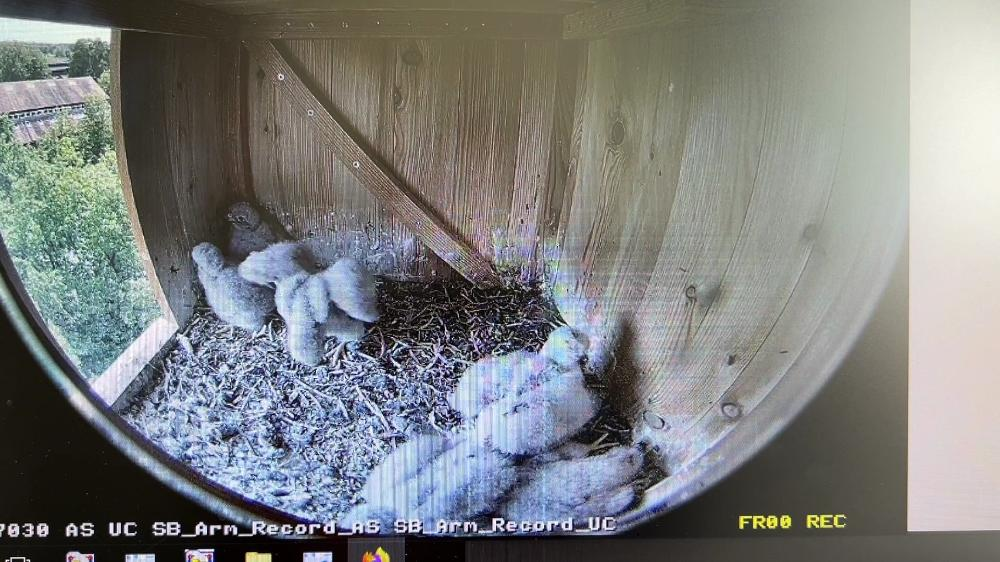
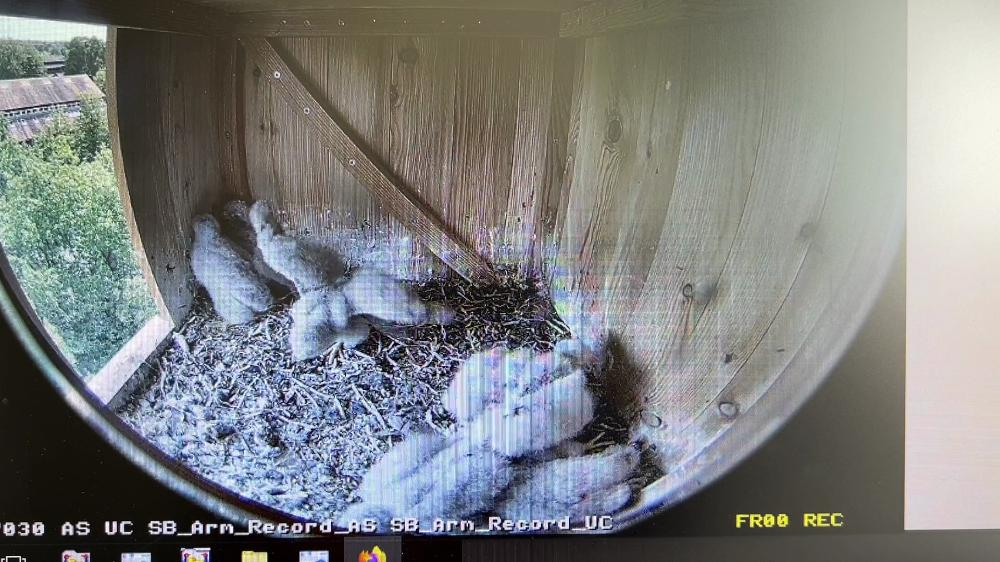
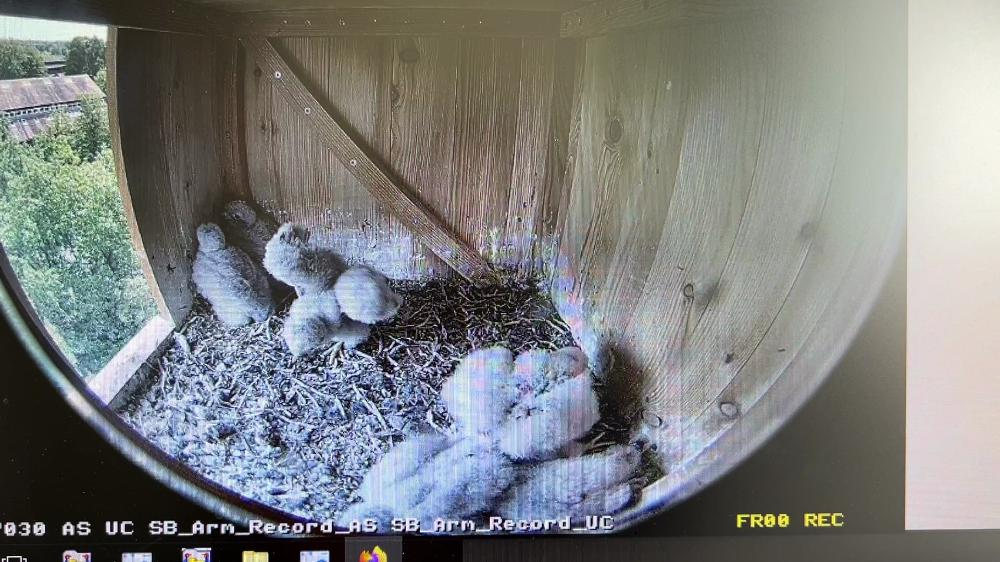
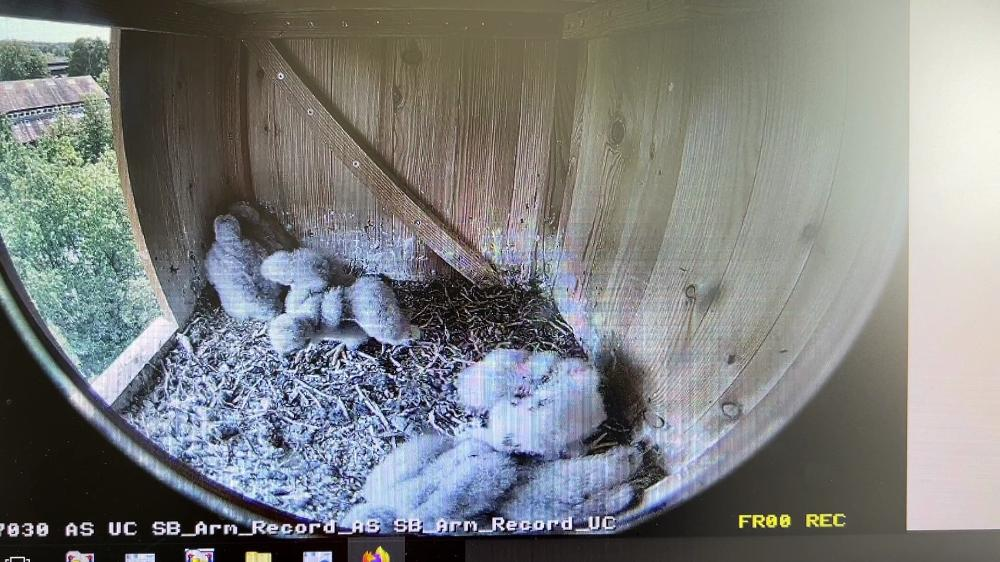
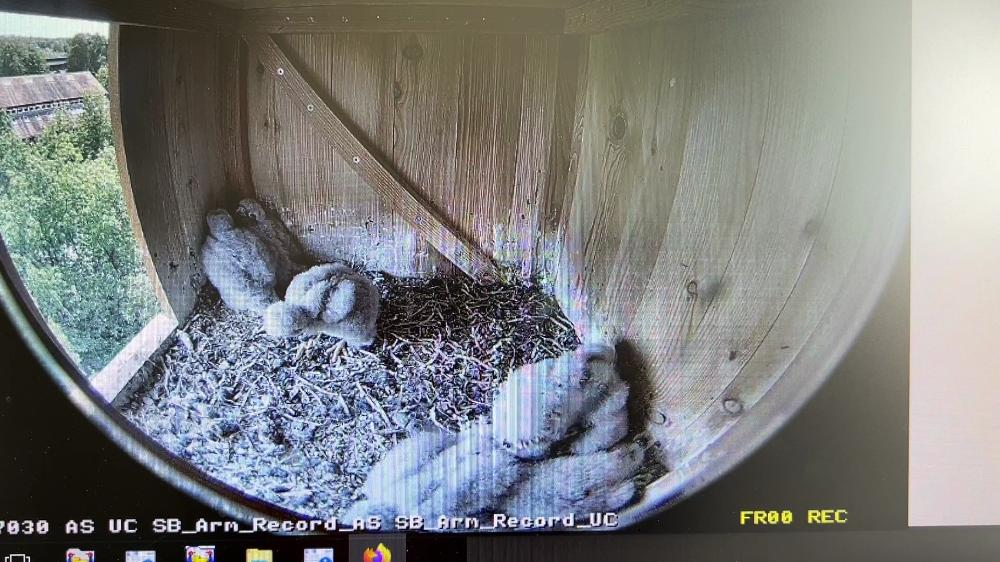

In [5]:
# let check what is inside

qp

In [15]:
# https://paquo.readthedocs.io/en/latest/quickstart.html

In [6]:
# i=9500
j=0

image = qp.images[j]
image.hierarchy.annotations


14:12:27.073 [main] [DEBUG] qupath.lib.io.PathIO - Read: {"dataVersion":3,"qupathVersion":"0.5.1","server":{"builderType":"uri","providerClassName":"qupath.lib.images.servers.bioformats.BioFormatsServerBuilder","uri":"file:/Users/vitaly/Lehre/WS2425/Falken/data/segment/0/2024-05-21_14:25:48_%C3%9Cben.MOV_15.jpg","args":["--series","0"],"metadata":{"name":"2024-05-21_14:25:48_Üben.MOV_15.jpg","width":1920,"height":1080,"sizeZ":1,"sizeT":1,"channelType":"DEFAULT","isRGB":true,"pixelType":"UINT8","levels":[{"downsample":1.0,"width":1920,"height":1080}],"channels":[{"name":"Red","color":-65536},{"name":"Green","color":-16711936},{"name":"Blue","color":-16776961}],"pixelCalibration":{"pixelWidth":{"value":1.0,"unit":"px"},"pixelHeight":{"value":1.0,"unit":"px"},"zSpacing":{"value":1.0,"unit":"z-slice"},"timeUnit":"SECONDS","timepoints":[]},"preferredTileWidth":1920,"preferredTileHeight":1080}},"id":"BioFormatsImageServer: file:/Users/vitaly/Lehre/WS2425/Falken/data/segment/0/2024-05-21_14:

<PathObjectProxy hierarchy=Hierarchy(image=2024-05-21_14:25:48_Üben.MOV_15.jpg, annotations=2, detections=0) paquo_cls=QuPathPathAnnotationObject mask=None at 0x0x1695b5100>

In [7]:
for el in image.hierarchy.annotations:
    # print(el.__dir__())
    u = el.to_geojson()
    print(u['geometry'])
    # print(el['geometry'])
    # for x in el:
    #     print(x)

{'type': 'Polygon', 'coordinates': [[[1071, 627], [1066, 628], [1065, 628], [1062, 630], [1061, 630], [1061, 631], [1059, 631], [1059, 633], [1058, 633], [1058, 634], [1058, 635], [1058, 637], [1056, 638], [1056, 640], [1056, 641], [1055, 641], [1055, 643], [1055, 644], [1053, 644], [1053, 646], [1052, 646], [1052, 647], [1050, 647], [1050, 649], [1050, 650], [1049, 650], [1049, 651], [1047, 651], [1047, 653], [1047, 654], [1046, 654], [1046, 656], [1046, 657], [1045, 659], [1045, 660], [1043, 662], [1043, 663], [1043, 664], [1042, 664], [1042, 666], [1042, 667], [1040, 669], [1040, 670], [1039, 672], [1039, 673], [1037, 675], [1037, 676], [1036, 676], [1036, 678], [1034, 679], [1033, 680], [1031, 680], [1031, 682], [1030, 680], [1029, 680], [1027, 679], [1023, 679], [1021, 678], [1017, 678], [1017, 676], [1014, 676], [1013, 675], [994, 675], [992, 676], [991, 676], [989, 678], [981, 678], [981, 679], [979, 679], [976, 680], [975, 680], [972, 682], [970, 682], [967, 683], [963, 683], [

In [7]:
image.image_name

'2024-05-21_14:25:48_Üben.MOV_15.jpg'

[[[ 63  58  57]
  [ 61  56  55]
  [ 60  55  54]
  ...
  [197 209 209]
  [196 208 208]
  [196 208 208]]

 [[ 63  58  57]
  [ 62  57  56]
  [ 61  56  55]
  ...
  [197 209 209]
  [196 208 208]
  [196 208 208]]

 [[ 64  59  58]
  [ 64  59  58]
  [ 63  58  57]
  ...
  [197 209 209]
  [197 209 209]
  [196 208 208]]

 ...

 [[ 14  19  22]
  [ 12  19  22]
  [ 10  19  22]
  ...
  [ 91  98 101]
  [ 91  98 101]
  [ 93 100 103]]

 [[ 14  19  22]
  [ 12  19  22]
  [ 10  19  22]
  ...
  [ 92  99 102]
  [ 92  99 102]
  [ 93 100 103]]

 [[ 14  19  22]
  [ 12  19  22]
  [  9  18  21]
  ...
  [ 92  99 102]
  [ 92  99 102]
  [ 93 100 103]]]


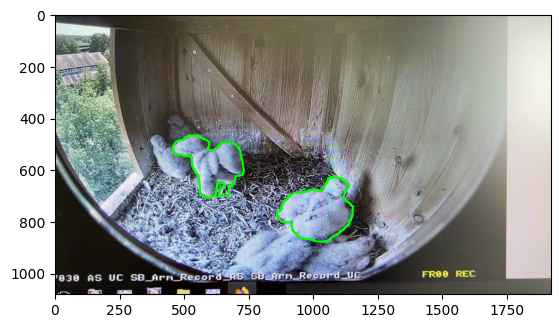

In [8]:
#### from numpy import *
from collections import Counter
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
# import matplotlib.ti


import cv2


# PATH_ = '/Users/vitaly/Lehre/WS2425/Falken/data/age_pt/train/0/'
PATH_ = '/Users/vitaly/Lehre/WS2425/Falken/data/segment/0/'
# Load the image
image_cv = cv2.imread(PATH_ + image.image_name, 1)
 
print(image_cv)

# Display the image in a window
cv2.imshow("Displayed Image", image_cv)
img2 = image_cv[:,:,::-1]
plt.imshow(img2)

scale = 1.0
# for el in image.hierarchy.annotations:
#     u = el.to_geojson()
for el in image.hierarchy.annotations:
    # print(el.__dir__())
    u = el.to_geojson()
    
    coords = u['geometry']['coordinates'][0]

    scaled = [(x * scale, y * scale) for x, y in coords]
    xs, ys = zip(*scaled)
    plt.plot(xs + (xs[0],), ys + (ys[0],), '-', color='lime', linewidth=1.5)



#cv2.waitKey(0)
#cv2.destroyAllWindows()


In [9]:
#https://forum.image.sc/t/misalignment-issue-in-visualizing-qupath-geojson-annotations-on-whole-slide-images/113363
#